# Example: Inference Pipeline from a Single Image

This notebook demonstrates an end-to-end inference pipeline inspired by the paper  
**[Facial Wrinkle Segmentation for Cosmetic Dermatology: Pretraining with Texture Map-Based Weak Supervision](https://arxiv.org/abs/2408.10060)**.

It includes:
- Uploading and preprocessing a single image
- Face parsing using BiSeNet
- Texture map generation
- Running a UNet-based inference
- Visualizing predictions and overlays

No GPU required — automatically falls back to CPU.  
For more details, see `example/README.md`.

**Author**: Hoai Linh Dao  
[GitHub](https://github.com/dhlinhdn00) | daohoailinhdn00@gmail.com


# **SETUP**

In [34]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
%cd /content/drive/MyDrive/

# !git clone https://github.com/labhai/ffhq-wrinkle-dataset.git

%cd ffhq-wrinkle-dataset

#
# !git clone -q https://github.com/zllrunning/face-parsing.PyTorch.git
# !mv face-parsing.PyTorch face_parsing && \
# %cd face_parsing

# !pip install -q gdown
# !mkdir -p res/cp
# !gdown 154JgKpzCPW82qINcVieuPH3fZ2e0P812 -O res/cp/79999_iter.pth
# %cd ..
! pip install -q --upgrade pip > /dev/null 2>&1 && \
! pip install -q -r requirements.txt > /dev/null 2>&1 && \
! pip install --no-cache-dir numpy==1.26.4 protobuf==4.25.3 mediapipe==0.10.20 opencv-python-headless tqdm==4.64.1 albumentations==1.3.0> /dev/null 2>&1



/content/drive/MyDrive
/content/drive/MyDrive/ffhq-wrinkle-dataset


In [ ]:
import os, sys, glob, cv2, uuid, subprocess, numpy as np, torch, matplotlib.pyplot as plt
from google.colab import files
from torchvision import transforms
BASE = "/content/drive/MyDrive/ffhq-wrinkle-dataset"
# sys.path.append(BASE)
sys.path.append(os.path.join(BASE, "face_parsing"))
from face_parsing.model import BiSeNet
from matplotlib.patches import Patch


In [ ]:
CKPT = f"{BASE}/checkpoints/stage2_wrinkle_finetune_unet/stage2_unet.pth"
FACEPARSING_CKPT = f"{BASE}/face_parsing/res/cp/79999_iter.pth"

paths = {
    "input":      os.path.join(BASE, "results", "inputs"),
    "img1024":    os.path.join(BASE, "results", "images1024x1024"),
    "parsed_npy": os.path.join(BASE, "results", "face_parsed_labels"),
    "masked":     os.path.join(BASE, "results", "masked_face_images"),
    "weak":       os.path.join(BASE, "results", "weak_wrinkle_masks"),
    "result":     os.path.join(BASE, "results", "ouputs"),
}
for p in paths.values(): os.makedirs(p, exist_ok=True)

# **MAIN**

In [39]:
def run():
    id = uuid.uuid4().hex[:6]
    uid      = id + ".png"
    uploaded = files.upload()
    fname    = next(iter(uploaded))
    raw_dst  = os.path.join(paths["input"], uid)
    cv2.imwrite(raw_dst, cv2.imread(fname))
    print("[INITIALIZED] Set Input ID as ", id)
    print("[FINISHED-0] Saved raw input:", raw_dst)
    img      = cv2.imread(fname)
    h, w     = img.shape[:2]
    side     = max(h, w)
    pad      = [(side-h)//2, side-h-(side-h)//2, (side-w)//2, side-w-(side-w)//2]
    sq       = cv2.copyMakeBorder(img,*pad,cv2.BORDER_REFLECT)
    sq       = cv2.resize(sq,(1024,1024),cv2.INTER_AREA)
    cv2.imwrite(os.path.join(paths["img1024"], uid), sq)
    print("[FINISHED-1] Saved resized image:", uid)

    DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
    net    = BiSeNet(n_classes=19)
    net.load_state_dict(torch.load(
        FACEPARSING_CKPT,
        map_location=DEVICE))
    net.to(DEVICE).eval()

    to_tensor = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),
    ])

    im512 = cv2.resize(sq,(512,512),cv2.INTER_AREA)
    with torch.no_grad():
        out     = net(to_tensor(im512).unsqueeze(0).to(DEVICE))[0]
    parsing   = out.argmax(1).squeeze().cpu().numpy().astype(np.uint8)
    npy_path  = os.path.join(paths["parsed_npy"], uid[:-4]+".npy")
    np.save(npy_path, parsing)
    print("[FINISHED-2] Saved face_parsed_labels:", os.path.basename(npy_path))

    mask_face = (parsing==1) | (parsing==10)
    mask_1024 = cv2.resize(mask_face.astype(np.uint8),
                          (1024,1024), cv2.INTER_NEAREST)

    masked_rgb = sq.copy()
    masked_rgb[mask_1024==0] = 0
    cv2.imwrite(os.path.join(paths["masked"], uid), masked_rgb)
    print("[FINISHED-3] Saved masked RGB:", uid)

    gray = cv2.cvtColor(sq, cv2.COLOR_BGR2GRAY).astype(np.float32)
    blur = cv2.GaussianBlur(gray, (21,21), 5)
    texture = (gray * 255.0) / (blur + 1.0)
    texture = 255. - np.clip(texture, 0, 255)
    texture = texture.astype(np.uint8)
    texture[mask_1024==0] = 0
    cv2.imwrite(os.path.join(paths["weak"], uid), texture)
    print("[FINISHED-4] Saved masked texture:", uid)

    try:
        subprocess.run([
            "python", os.path.join(BASE,"inference.py"),
            "--image_path",   paths["masked"],
            "--texture_path", paths["weak"],
            "--network",      "UNet",
            "--num_channels","4",
            "--num_classes", "2",
            "--checkpoint",   CKPT,
            "--gpu_id",       "0",
            "--img_size",     "1024",
            "--output_dir",   paths["result"],
        ], check=True)
    except subprocess.CalledProcessError as e:
        print("---INFERENCE FAILED---")
        raise

    print("[FINISHED] Result in:", paths["result"])
    os.remove(fname)

def show():
    COLOR = (0, 0, 255)  # BGR
    ALPHA = 0.4

    def show_one(uid):
        p = {
            "orig": os.path.join(paths["img1024"], uid),
            "masked": os.path.join(paths["masked"], uid),
            "tex": os.path.join(paths["weak"], uid),
            "mask": os.path.join(paths["result"], uid.replace(".png", "_mask.png")),
        }
        if not all(os.path.exists(x) for x in p.values()):
            print(f"Lack of file for {uid} => Skipped.")
            return
        img_orig   = cv2.cvtColor(cv2.imread(p["orig"]), cv2.COLOR_BGR2RGB)
        img_masked = cv2.cvtColor(cv2.imread(p["masked"]), cv2.COLOR_BGR2RGB)
        img_tex    = cv2.imread(p["tex"],  cv2.IMREAD_GRAYSCALE)
        pred_mask  = cv2.imread(p["mask"], cv2.IMREAD_GRAYSCALE)

        overlay = img_orig.copy()
        clr = np.zeros_like(overlay)
        clr[..., 0], clr[..., 1], clr[..., 2] = COLOR[2], COLOR[1], COLOR[0]
        m = pred_mask > 0
        overlay[m] = cv2.addWeighted(overlay[m], 1-ALPHA, clr[m], ALPHA, 0)

        titles = ["Original", "Masked RGB", "Texture map", "Predicted mask", "Overlay"]
        imgs   = [img_orig, img_masked, img_tex, pred_mask, overlay]

        plt.figure(figsize=(20,4))
        for i, (im,t) in enumerate(zip(imgs,titles),1):
            ax = plt.subplot(1,5,i)
            ax.imshow(im, cmap="gray" if im.ndim==2 else None)
            ax.set_title(t); ax.axis("off")
        plt.suptitle(uid, fontsize=15); plt.tight_layout(); plt.show()

    query = input("Enter ID or 'all' to show all: ").strip()
    if not query:
        print("Nothing - Force to Stop")
    elif query.lower() == "all":
        uids = sorted(
            os.path.basename(p)
            for p in glob.glob(os.path.join(paths["img1024"], "*.png"))
        )
        if not uids:
            print("Not found image in", paths["img1024"])
        for uid in uids: show_one(uid)
    else:
        if not query.endswith(".png"): query += ".png"
        show_one(query)


In [47]:
run()

Saving 305f2f4c9ea42cfa75b5.jpg to 305f2f4c9ea42cfa75b5.jpg
[INITIALIZED] Set Input ID as  779500
[FINISHED-0] Saved raw input: /content/drive/MyDrive/ffhq-wrinkle-dataset/results/inputs/779500.png
[FINISHED-1] Saved resized image: 779500.png
[FINISHED-2] Saved face_parsed_labels: 779500.npy
[FINISHED-3] Saved masked RGB: 779500.png
[FINISHED-4] Saved masked texture: 779500.png
[FINISHED] Result in: /content/drive/MyDrive/ffhq-wrinkle-dataset/results/ouputs


Enter ID or 'all' to show all: 779500


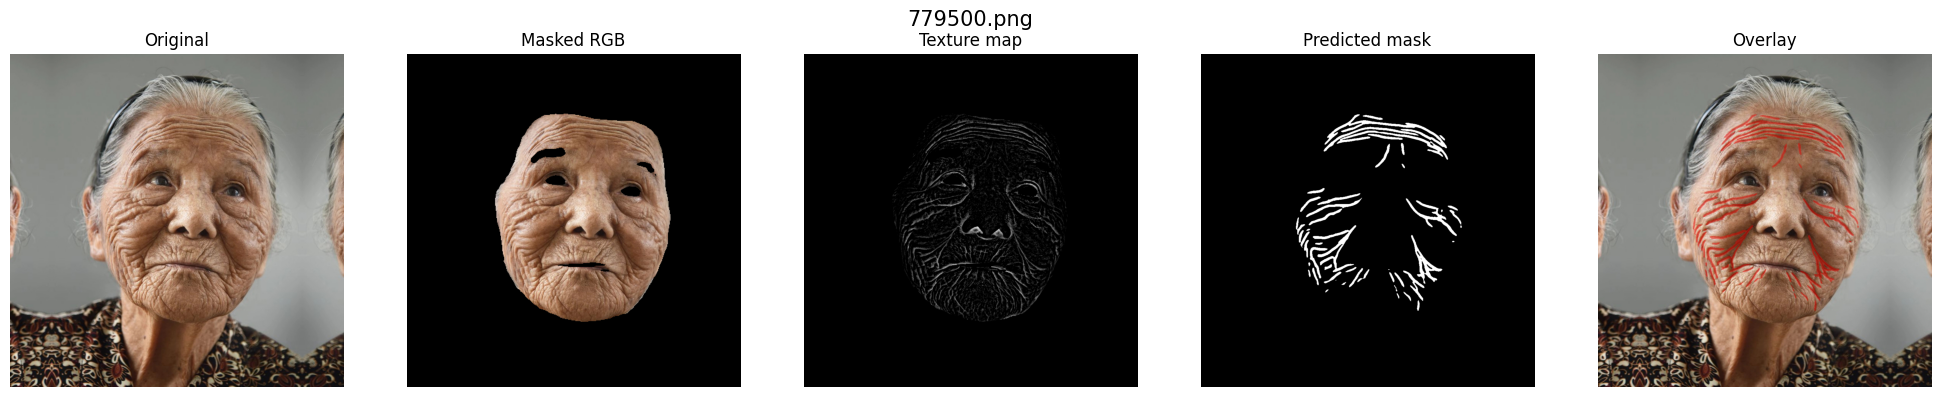

In [48]:
show()